<a href="https://colab.research.google.com/github/RAMKARTHIKCR/Ram_Karthik_R/blob/main/MRI_EIGEN_VALUE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

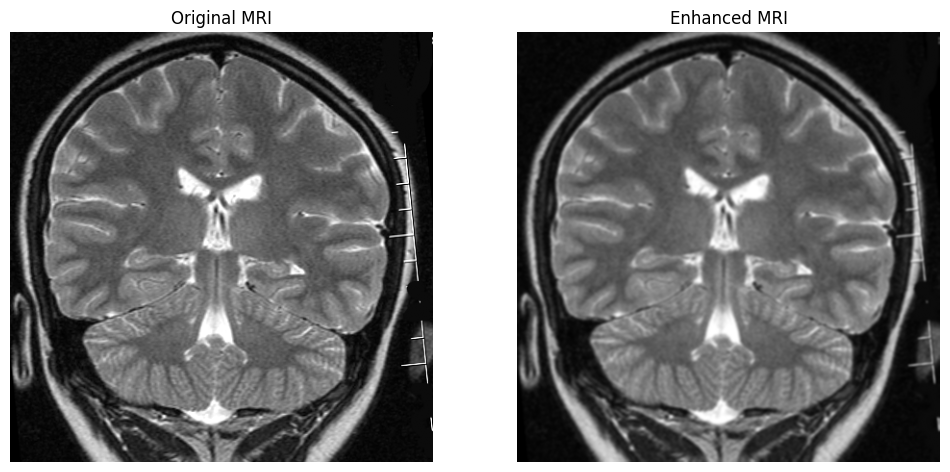

Enhanced MRI image saved successfully.


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Read MRI image
img = cv2.imread('/content/MRI.png', cv2.IMREAD_GRAYSCALE)

if img is None:
    print("Image not found")

else:

    # Display original MRI
    plt.figure(figsize=(12,6))

    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original MRI")
    plt.axis('off')

    # Convert image to float
    A = np.float64(img)

    # Gaussian Blur
    A_blur = cv2.GaussianBlur(A, (5,5), 0)

    # Singular Value Decomposition
    U, S, VT = np.linalg.svd(A_blur, full_matrices=False)

    # Enhance singular values
    S_enhanced = S * 1.5

    # Create diagonal matrix
    Sigma = np.diag(S_enhanced)

    # Reconstruct enhanced image
    Enhanced = U @ Sigma @ VT

    # Normalize image
    Enhanced = cv2.normalize(
        Enhanced,
        None,
        0,
        255,
        cv2.NORM_MINMAX
    )

    # Convert to uint8
    Enhanced = np.uint8(Enhanced)

    # Display enhanced MRI
    plt.subplot(1,2,2)
    plt.imshow(Enhanced, cmap='gray')
    plt.title("Enhanced MRI")
    plt.axis('off')

    plt.show()

    # Save output
    cv2.imwrite('/content/enhanced_MRI.png', Enhanced)

    print("Enhanced MRI image saved successfully.")